In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
def f(x):
  return 3 * x**2 - 4 * x + 5

In [18]:
f(3.0)

20.0

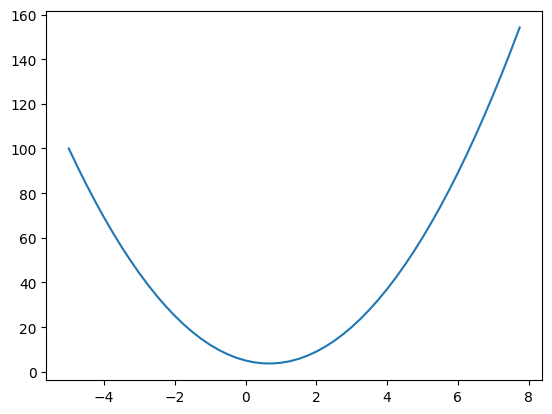

In [19]:
xs = np.arange(-5, 8, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [20]:
h = 0.0000001
x = -3.0
(f(x + h) - f(x)) / h

-21.999999688659955

In [21]:
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [23]:
h = 0.000001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
a += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 3.9999969999999996
slope -3.000000000419334


In [55]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f'Value(data = {self.data})'

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out

a = Value(2.0, label='a')
b = Value(-6.0, label='b')
c = Value(5.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(7.0, label='f')
L = d * f; L.label = 'L'
L

Value(data = -49.0)

In [38]:
d._prev

{Value(data = -6.0), Value(data = 5.0)}

In [39]:
d._op

'+'

In [56]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f}" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

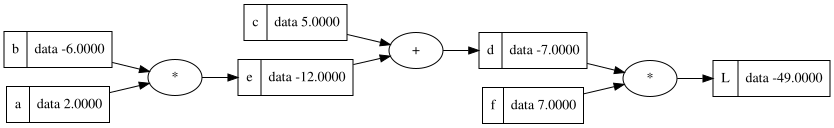

In [58]:
draw_dot(L)